In [1]:
import numpy as np
import sys
sys.path.insert(0, '../src/')
from oz import PyOZ
import matplotlib.pyplot as plt

In [2]:
def ulj(r,params):
    [sigma,eps] = params
    return 4*eps*((sigma/r)**12-(sigma/r)**6)

In [3]:
sigma=1.0
eps=1.0

In [4]:
ljHNC = PyOZ(ulj,params=[sigma,eps],closure='HNC')
ljPY = PyOZ(ulj,params=[sigma,eps],closure='PY')

Defining the grid size

In [5]:
dr = 0.01

Problema com o algoritmo em alta densidade

In [6]:
kT = 0.71
rhob = 0.84

## Testing convergence speed at kT = 0.71 and rhob = 0.84

In [7]:
import timeit

alphaarray = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])
timesPicard = []
for i, alpha in enumerate(alphaarray):
    execution_time = timeit.timeit(lambda: ljHNC.solve(rho=rhob, kBT=kT, rmax = 8.0, dr=dr, method='Picard', alpha=alpha), number=10)
    timesPicard.append(execution_time/10)
    print(f"Alpha: {alpha}, Execution Time: {execution_time/10:.4f} seconds")

Alpha: 0.1, Execution Time: 0.1623 seconds
Alpha: 0.2, Execution Time: 0.1545 seconds
Alpha: 0.3, Execution Time: 0.1507 seconds
Alpha: 0.4, Execution Time: 0.1519 seconds
Alpha: 0.5, Execution Time: 0.1514 seconds
Alpha: 0.6, Execution Time: 0.1479 seconds
Alpha: 0.7, Execution Time: 0.1533 seconds
Alpha: 0.8, Execution Time: 0.1587 seconds
Alpha: 0.9, Execution Time: 0.1094 seconds


Text(0.5, 1.0, 'Picard Iteration Convergence Time vs Alpha')

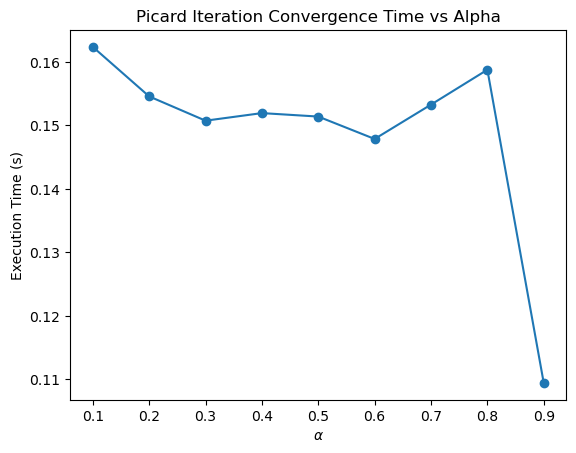

In [8]:
plt.plot(alphaarray,timesPicard,'-o',label='Picard')
plt.xlabel(r'$\alpha$')
plt.ylabel('Execution Time (s)')
plt.title('Picard Iteration Convergence Time vs Alpha')

In [9]:
mixdepth = np.array([2,3,4,5,6,7,8,9], dtype=np.int16)
timesAnderson = []
for i, mix in enumerate(mixdepth):
    execution_time = timeit.timeit(lambda: ljHNC.solve(rho=rhob, kBT=kT, rmax = 8.0, dr=dr, method='Anderson', mix_depth=mix), number=10)
    timesAnderson.append(execution_time/10)
    print(f"Mixing Depth: {mix}, Execution Time: {execution_time/10:.4f} seconds")

Mixing Depth: 2, Execution Time: 0.0205 seconds
Mixing Depth: 3, Execution Time: 0.0081 seconds
Mixing Depth: 4, Execution Time: 0.0075 seconds
Mixing Depth: 5, Execution Time: 0.0071 seconds
Mixing Depth: 6, Execution Time: 0.0068 seconds
Mixing Depth: 7, Execution Time: 0.0065 seconds
Mixing Depth: 8, Execution Time: 0.0071 seconds
Mixing Depth: 9, Execution Time: 0.0122 seconds


Text(0.5, 1.0, 'Anderson Mixing Convergence Time vs Mixing Depth')

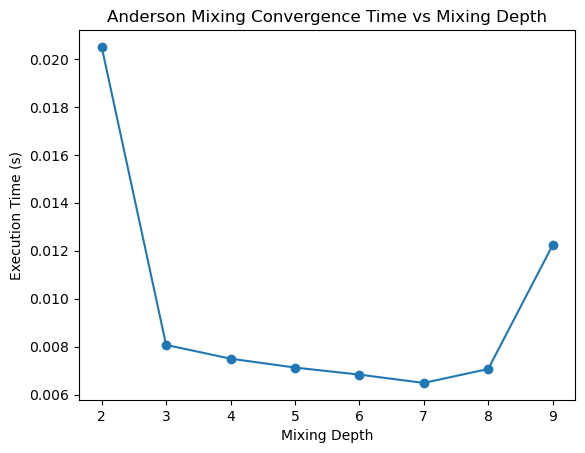

In [10]:
plt.plot(mixdepth,timesAnderson,'-o',label='Anderson')
plt.xlabel('Mixing Depth')
plt.ylabel('Execution Time (s)')
plt.title('Anderson Mixing Convergence Time vs Mixing Depth')

In [11]:
timesAnderson = []
for i, alpha in enumerate(alphaarray):
    execution_time = timeit.timeit(lambda: ljHNC.solve(rho=rhob, kBT=kT, rmax = 8.0, dr=dr, method='Anderson', alpha = alpha), number=10)
    timesAnderson.append(execution_time/10)
    print(f"Alpha: {alpha}, Execution Time: {execution_time/10:.4f} seconds")

Alpha: 0.1, Execution Time: 0.2465 seconds
Alpha: 0.2, Execution Time: 0.2413 seconds
Alpha: 0.3, Execution Time: 0.0076 seconds
Alpha: 0.4, Execution Time: 0.0085 seconds
Alpha: 0.5, Execution Time: 0.0077 seconds
Alpha: 0.6, Execution Time: 0.0069 seconds
Alpha: 0.7, Execution Time: 0.2423 seconds
Alpha: 0.8, Execution Time: 0.2365 seconds
Alpha: 0.9, Execution Time: 0.0100 seconds


Text(0, 0.5, 'Execution Time (s)')

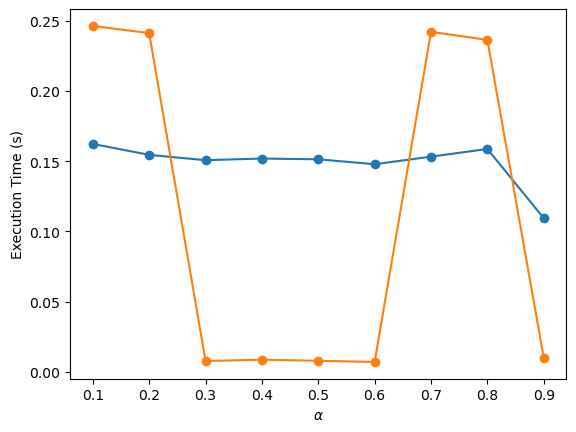

In [12]:
plt.plot(alphaarray,timesPicard,'-o',label='Picard')
plt.plot(alphaarray,timesAnderson,'-o',label='Anderson')
plt.xlabel(r'$\alpha$')
plt.ylabel('Execution Time (s)')
# plt.title('Picard Iteration Convergence Time vs Alpha')

NOTE: Anderson method (with mix_depth=5) is 10 times faster than Picard method at high densities and low temperatures. 